# Phase 0 (Obj A): Lucas-Style Motivation and Replication

This notebook builds the motivation layer: a Lucas-style cross-country comparison between money growth, inflation, and GDP growth.

## What this notebook does

1. Loads the merged country-year panel.
2. Re-runs pooled associations (money growth -> inflation, money growth -> GDP growth).
3. Re-runs Lucas-style long-run country-average comparisons.
4. Exports phase-0 summary tables for downstream phases.

In [4]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid")


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "02_data/analysis_ready/macro_growth_merged.csv").exists():
            return candidate
    raise FileNotFoundError("Could not find project root with analysis-ready data.")


ROOT = find_project_root(Path.cwd().resolve())
PANEL_PATH = ROOT / "02_data/analysis_ready/macro_growth_merged.csv"
OUT_DIR = ROOT / "03_analysis_notebooks/exports/phase0"
OUT_DIR.mkdir(parents=True, exist_ok=True)
ROOT

PosixPath('/Users/stevenchung/Desktop/P12B_File/Monetary_Panel')

In [5]:
df = pd.read_csv(PANEL_PATH)
df = df.rename(columns={"Country Name": "country"})

summary = pd.DataFrame({
    "metric": ["rows", "countries", "year_min", "year_max"],
    "value": [len(df), df["country"].nunique(), int(df["year"].min()), int(df["year"].max())],
})
summary

,metric,value
0,rows,4292
1,countries,163
2,year_min,1991
3,year_max,2020


In [6]:
pooled_infl = smf.ols("inflation ~ m2_growth", data=df.dropna(subset=["inflation", "m2_growth"])).fit(cov_type="HC1")
pooled_gdp = smf.ols("gdp_growth ~ m2_growth", data=df.dropna(subset=["gdp_growth", "m2_growth"])).fit(cov_type="HC1")

pooled_results = pd.DataFrame([
    {
        "model": "pooled_inflation",
        "coef_m2_growth": float(pooled_infl.params["m2_growth"]),
        "p_value": float(pooled_infl.pvalues["m2_growth"]),
        "adj_r2": float(pooled_infl.rsquared_adj),
        "nobs": int(pooled_infl.nobs),
    },
    {
        "model": "pooled_gdp_growth",
        "coef_m2_growth": float(pooled_gdp.params["m2_growth"]),
        "p_value": float(pooled_gdp.pvalues["m2_growth"]),
        "adj_r2": float(pooled_gdp.rsquared_adj),
        "nobs": int(pooled_gdp.nobs),
    },
])
pooled_results

,model,coef_m2_growth,p_value,adj_r2,nobs
0,pooled_inflation,0.645068,5.114322e-07,0.524552,4292
1,pooled_gdp_growth,-0.001012,8.687072e-01,-0.000210,4292


In [7]:
country_avg = (
    df.groupby("country", as_index=False)
    .agg(
        m2_growth=("m2_growth", "mean"),
        inflation=("inflation", "mean"),
        gdp_growth=("gdp_growth", "mean"),
        n_obs=("year", "count"),
    )
)
country_avg_30 = country_avg[country_avg["n_obs"] >= 30].copy()

longrun_infl = smf.ols("inflation ~ m2_growth", data=country_avg_30.dropna(subset=["inflation", "m2_growth"])).fit()
longrun_gdp = smf.ols("gdp_growth ~ m2_growth", data=country_avg_30.dropna(subset=["gdp_growth", "m2_growth"])).fit()

longrun_results = pd.DataFrame([
    {
        "model": "longrun_inflation_country_avg",
        "coef_m2_growth": float(longrun_infl.params["m2_growth"]),
        "p_value": float(longrun_infl.pvalues["m2_growth"]),
        "adj_r2": float(longrun_infl.rsquared_adj),
        "nobs": int(longrun_infl.nobs),
    },
    {
        "model": "longrun_gdp_country_avg",
        "coef_m2_growth": float(longrun_gdp.params["m2_growth"]),
        "p_value": float(longrun_gdp.pvalues["m2_growth"]),
        "adj_r2": float(longrun_gdp.rsquared_adj),
        "nobs": int(longrun_gdp.nobs),
    },
])
longrun_results

,model,coef_m2_growth,p_value,adj_r2,nobs
0,longrun_inflation_country_avg,0.890939,2.842661e-38,0.863314,86
1,longrun_gdp_country_avg,0.061564,3.204681e-02,0.042285,86


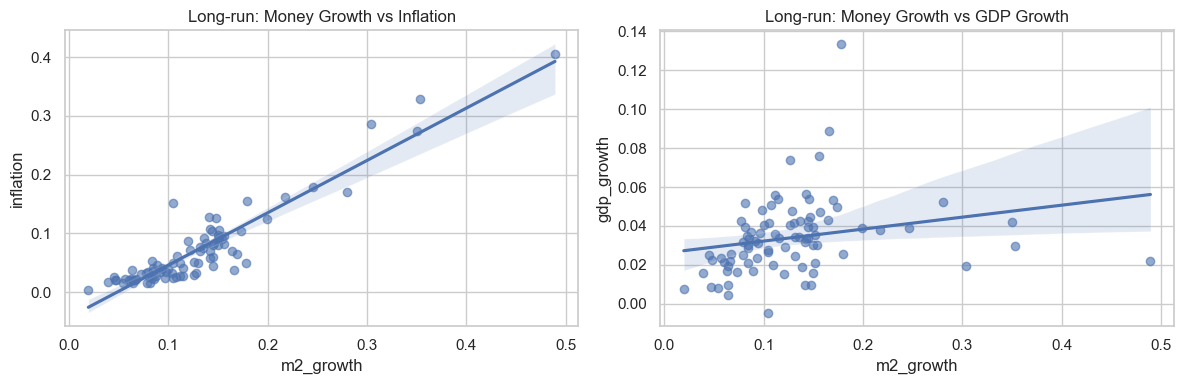

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.regplot(data=country_avg_30, x="m2_growth", y="inflation", scatter_kws={"alpha": 0.6}, ax=axes[0])
axes[0].set_title("Long-run: Money Growth vs Inflation")

sns.regplot(data=country_avg_30, x="m2_growth", y="gdp_growth", scatter_kws={"alpha": 0.6}, ax=axes[1])
axes[1].set_title("Long-run: Money Growth vs GDP Growth")

fig.tight_layout()
fig.savefig(OUT_DIR / "phase0_longrun_scatter.png", dpi=170)
plt.show()

In [9]:
pooled_results.to_csv(OUT_DIR / "phase0_pooled_results.csv", index=False)
longrun_results.to_csv(OUT_DIR / "phase0_longrun_results.csv", index=False)
country_avg_30.to_csv(OUT_DIR / "phase0_country_averages_n30.csv", index=False)
summary.to_csv(OUT_DIR / "phase0_sample_summary.csv", index=False)

print("Saved Phase 0 outputs to:", OUT_DIR)

Saved Phase 0 outputs to: /Users/stevenchung/Desktop/P12B_File/Monetary_Panel/outputs/notebook_phase0


## Interpretation for Obj A

- If inflation loads strongly on money growth in pooled and long-run country-average views, Obj A motivation is supported.
- GDP-growth links are expected to be weaker and should be treated cautiously.
- Move to Phase 1 for FE/IV baseline modeling under Obj B.